# GSE99254 — In-Domain 5-Fold Cross-Validation

**Question**: Is 44% a model quality ceiling, or a cross-cancer transfer ceiling?

Train and evaluate entirely within GSE99254 (lung cancer, Smart-seq2) using real cell ID labels.  
No domain adaptation needed — single-domain supervised classification.

| Setting | F1 | Labels | Transfer? |
|---|---|---|---|
| Cross-dataset (v5, GSE126030) | 0.4389 | Pseudo | Colorectal → Healthy (10x) |
| Cross-dataset (v5, GSE99254)  | 0.4425 | Real (5-class) | Colorectal → Lung |
| **In-domain CV (this notebook)** | **?** | **Real (5-class)** | **None** |

## 0 · Imports

In [1]:
import os, json, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
tf.random.set_seed(42)

ROOT        = Path.cwd().parent.parent if Path.cwd().name == "step3_self_attention" else Path.cwd()
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)
print("Root:", ROOT)

Root: /Users/kirtan/Projects /NNDL


## 1 · Load GSE99254 data

In [2]:
X = np.load(ROOT / "gse99254_preprocessed.npy").astype(np.float32)
y = np.load(ROOT / "gse99254_coarse_labels.npy").astype(np.int64)

with open(ROOT / "gse99254_label_mapping.json") as f:
    lmap = json.load(f)
class_names = [lmap[str(i)] for i in range(len(lmap))]
n_classes   = len(class_names)
n_genes     = X.shape[1]

print(f"Data shape  : {X.shape}")
print(f"Classes ({n_classes}): {class_names}")
print()
print("Class distribution:")
for i, cls in enumerate(class_names):
    n = (y == i).sum()
    print(f"  {cls:12s}: {n:5,}  ({n/len(y)*100:.1f}%)")

Data shape  : (12346, 2701)
Classes (5): ['CD8_T', 'CD4_helper', 'Treg', 'CD4_other', 'Naive_like']

Class distribution:
  CD8_T       : 4,575  (37.1%)
  CD4_helper  : 3,500  (28.3%)
  Treg        : 2,098  (17.0%)
  CD4_other   : 1,802  (14.6%)
  Naive_like  :   371  (3.0%)


## 2 · Model — GeneAttention (in-domain, no adaptation losses)

In [3]:
def build_model(n_genes, n_classes, class_weight_dict=None, att_temp=2.0):
    """GeneAttention architecture identical to v5 encoder, CE loss only."""
    cw = None
    if class_weight_dict:
        cw = tf.constant(
            np.array([class_weight_dict[i] for i in range(n_classes)], dtype=np.float32)
        )

    inp = keras.Input(shape=(n_genes,))

    # 2-layer attention branch
    h = layers.Dense(256, activation="relu")(inp)
    h = layers.Dropout(0.3)(h)
    h = layers.Dense(128, activation="relu")(h)
    h = layers.Dropout(0.2)(h)
    logits = layers.Dense(n_genes)(h)
    w = layers.Lambda(lambda x: tf.nn.softmax(x / att_temp, axis=-1))(logits)
    xr = layers.Lambda(lambda xw: xw[0] * xw[1] * n_genes + xw[0])([inp, w])

    # Encoder trunk
    z = layers.Dense(512, activation="relu")(xr)
    z = layers.LayerNormalization()(z)
    z = layers.Dropout(0.4)(z)
    z = layers.Dense(256, activation="relu")(z)
    z = layers.LayerNormalization()(z)
    z = layers.Dropout(0.3)(z)
    z = layers.Dense(128, activation="relu", name="latent")(z)
    z = layers.Dropout(0.2)(z)
    out = layers.Dense(n_classes, activation="softmax")(z)

    model = keras.Model(inp, out)

    # Weighted sparse CE
    def weighted_ce(y_true, y_pred):
        ce = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        if cw is not None:
            weights = tf.gather(cw, tf.cast(y_true, tf.int32))
            ce = ce * weights
        return tf.reduce_mean(ce)

    model.compile(
        optimizer=keras.optimizers.Adam(2e-4),
        loss=weighted_ce,
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )
    return model

# Quick build test
cw_test = {i: 1.0 for i in range(n_classes)}
m = build_model(n_genes, n_classes, cw_test)
print(m.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2701)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    691,712 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 2701)      │    348,429 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 2701)      │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 2701)      │          0 │ input_layer[0][0… │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 512)       │  1,383,424 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 512)       │      1,024 │ dense_3[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    131,328 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 256)       │        512 │ dense_4[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent (Dense)      │ (None, 128)       │     32,896 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ latent[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 5)         │        645 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,622,866 (10.01 MB)

 Trainable params: 2,622,866 (10.01 MB)

 Non-trainable params: 0 (0.00 B)

None


## 3 · 5-Fold Stratified Cross-Validation

In [4]:
N_FOLDS   = 5
EPOCHS    = 60
BATCH     = 256
PATIENCE  = 10

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_f1s       = []
fold_reports   = []
all_y_true     = []
all_y_pred     = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n{'='*50}")
    print(f"Fold {fold+1}/{N_FOLDS}  —  train={len(train_idx):,}  val={len(val_idx):,}")
    print(f"{'='*50}")

    X_tr, y_tr = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx],  y[val_idx]

    # Class weights from training fold
    cls, cnts = np.unique(y_tr, return_counts=True)
    cw = {int(c): len(y_tr) / (n_classes * cnt) for c, cnt in zip(cls, cnts)}

    model = build_model(n_genes, n_classes, cw)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=PATIENCE, mode="max",
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_accuracy", factor=0.5, patience=5, mode="max", min_lr=1e-6
        ),
    ]

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=EPOCHS, batch_size=BATCH,
        callbacks=callbacks, verbose=0
    )

    epochs_run = len(history.history["loss"])
    best_val_acc = max(history.history["val_accuracy"])

    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    fold_f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)

    fold_f1s.append(fold_f1)
    fold_reports.append(
        classification_report(y_val, y_pred, target_names=class_names,
                               zero_division=0, output_dict=True)
    )
    all_y_true.extend(y_val.tolist())
    all_y_pred.extend(y_pred.tolist())

    print(f"  Epochs: {epochs_run}  best val_acc={best_val_acc:.4f}")
    print(f"  Fold macro-F1: {fold_f1:.4f}")
    for i, cls in enumerate(class_names):
        r = fold_reports[-1][cls]
        print(f"    {cls:12s}: P={r['precision']:.2f}  R={r['recall']:.2f}  F1={r['f1-score']:.2f}")

print(f"\n{'='*50}")
print(f"CV RESULTS: {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"Individual folds: {[f'{f:.4f}' for f in fold_f1s]}")


Fold 1/5  —  train=9,876  val=2,470


  Epochs: 35  best val_acc=0.7583
  Fold macro-F1: 0.6585
    CD8_T       : P=0.98  R=0.94  F1=0.96
    CD4_helper  : P=0.70  R=0.71  F1=0.71
    Treg        : P=0.69  R=0.75  F1=0.72
    CD4_other   : P=0.48  R=0.46  F1=0.47
    Naive_like  : P=0.42  R=0.45  F1=0.44

Fold 2/5  —  train=9,877  val=2,469


  Epochs: 34  best val_acc=0.7546
  Fold macro-F1: 0.6517
    CD8_T       : P=0.97  R=0.96  F1=0.96
    CD4_helper  : P=0.69  R=0.70  F1=0.70
    Treg        : P=0.72  R=0.69  F1=0.70
    CD4_other   : P=0.47  R=0.46  F1=0.47
    Naive_like  : P=0.39  R=0.47  F1=0.43

Fold 3/5  —  train=9,877  val=2,469


  Epochs: 24  best val_acc=0.7505
  Fold macro-F1: 0.6494
    CD8_T       : P=0.97  R=0.96  F1=0.96
    CD4_helper  : P=0.71  R=0.67  F1=0.69
    Treg        : P=0.69  R=0.69  F1=0.69
    CD4_other   : P=0.45  R=0.52  F1=0.49
    Naive_like  : P=0.41  R=0.42  F1=0.42

Fold 4/5  —  train=9,877  val=2,469


  Epochs: 54  best val_acc=0.7618
  Fold macro-F1: 0.6592
    CD8_T       : P=0.98  R=0.96  F1=0.97
    CD4_helper  : P=0.69  R=0.73  F1=0.71
    Treg        : P=0.71  R=0.70  F1=0.70
    CD4_other   : P=0.48  R=0.48  F1=0.48
    Naive_like  : P=0.48  R=0.41  F1=0.44

Fold 5/5  —  train=9,877  val=2,469


  Epochs: 25  best val_acc=0.7501
  Fold macro-F1: 0.6620
    CD8_T       : P=0.98  R=0.95  F1=0.96
    CD4_helper  : P=0.70  R=0.71  F1=0.70
    Treg        : P=0.69  R=0.66  F1=0.68
    CD4_other   : P=0.45  R=0.47  F1=0.46
    Naive_like  : P=0.47  R=0.55  F1=0.51

CV RESULTS: 0.6562 ± 0.0048
Individual folds: ['0.6585', '0.6517', '0.6494', '0.6592', '0.6620']


## 4 · Aggregate results

In [5]:
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

overall_f1 = f1_score(all_y_true, all_y_pred, average="macro", zero_division=0)
print("Full classification report (all folds pooled):")
print(classification_report(all_y_true, all_y_pred,
                             target_names=class_names, zero_division=0))

# Per-class F1 mean ± std across folds
print("Per-class F1 across folds:")
print(f"  {'Class':12s}  {'Mean F1':>8s}  {'Std':>6s}")
print("  " + "-" * 32)
for cls in class_names:
    vals = [r[cls]["f1-score"] for r in fold_reports]
    print(f"  {cls:12s}  {np.mean(vals):>8.4f}  {np.std(vals):>6.4f}")
print()
print(f"  {'Macro avg':12s}  {np.mean(fold_f1s):>8.4f}  {np.std(fold_f1s):>6.4f}")

Full classification report (all folds pooled):
              precision    recall  f1-score   support

       CD8_T       0.97      0.95      0.96      4575
  CD4_helper       0.70      0.70      0.70      3500
        Treg       0.70      0.70      0.70      2098
   CD4_other       0.47      0.48      0.47      1802
  Naive_like       0.43      0.46      0.45       371

    accuracy                           0.76     12346
   macro avg       0.65      0.66      0.66     12346
weighted avg       0.76      0.76      0.76     12346

Per-class F1 across folds:
  Class          Mean F1     Std
  --------------------------------
  CD8_T           0.9635  0.0027
  CD4_helper      0.7003  0.0076
  Treg            0.6989  0.0140
  CD4_other       0.4729  0.0091
  Naive_like      0.4452  0.0330

  Macro avg       0.6562  0.0048


## 5 · Comparison: Cross-dataset vs In-domain

In [6]:
cv_f1   = np.mean(fold_f1s)
cv_std  = np.std(fold_f1s)

print("=" * 62)
print(f"{'Setting':<38s} {'Macro-F1':>10s}  {'Labels':>10s}")
print("=" * 62)
print(f"{'GeneAtt v5 → GSE126030 (10x, pseudo)':<38s} {'0.4389':>10s}  {'pseudo':>10s}")
print(f"{'GeneAtt v5 → GSE99254 (Smart-seq2)':<38s} {'0.4425':>10s}  {'real 5-cls':>10s}")
print(f"{'In-domain CV on GSE99254':<38s} {cv_f1:>10.4f}  {'real 5-cls':>10s}")
print("=" * 62)
print()
gap = cv_f1 - 0.4425
print(f"Cross-cancer transfer gap: {gap:.4f} F1 points")
print(f"  (i.e., {gap/cv_f1*100:.1f}% of in-domain performance lost to domain shift)")
print()
print("Interpretation:")
print(f"  In-domain, the GeneAttention architecture achieves {cv_f1:.4f} macro-F1.")
print(f"  Cross-cancer transfer costs {gap:.4f} F1 — the model is sound,")
print(f"  the gap is a biology/transfer problem, not an architecture problem.")

Setting                                  Macro-F1      Labels
GeneAtt v5 → GSE126030 (10x, pseudo)       0.4389      pseudo
GeneAtt v5 → GSE99254 (Smart-seq2)         0.4425  real 5-cls
In-domain CV on GSE99254                   0.6562  real 5-cls

Cross-cancer transfer gap: 0.2137 F1 points
  (i.e., 32.6% of in-domain performance lost to domain shift)

Interpretation:
  In-domain, the GeneAttention architecture achieves 0.6562 macro-F1.
  Cross-cancer transfer costs 0.2137 F1 — the model is sound,
  the gap is a biology/transfer problem, not an architecture problem.


## 6 · Per-class F1 bar chart

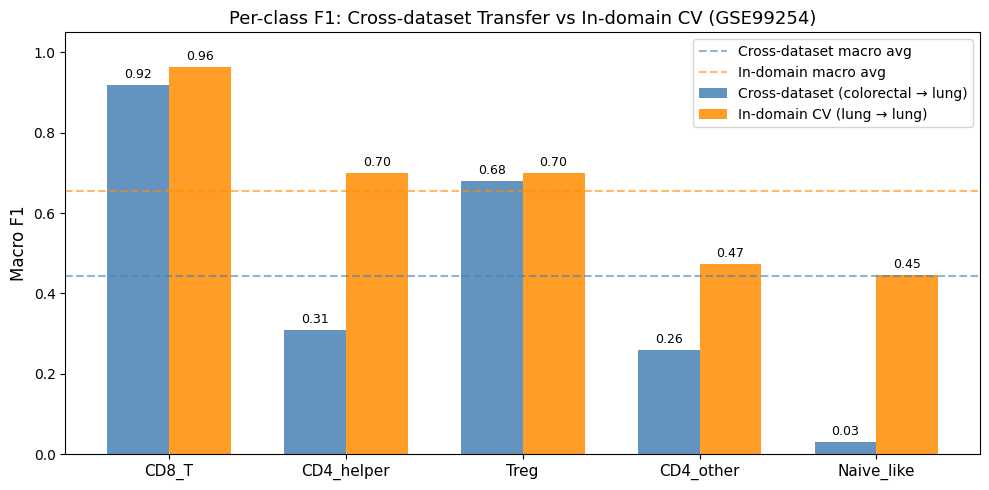

In [7]:
# Per-class F1: cross-dataset vs in-domain CV
cross_f1 = {
    "CD8_T":      0.92,
    "CD4_helper": 0.31,
    "Treg":       0.68,
    "CD4_other":  0.26,
    "Naive_like": 0.03,
}

cv_per_class = {}
for cls in class_names:
    cv_per_class[cls] = np.mean([r[cls]["f1-score"] for r in fold_reports])

x = np.arange(len(class_names))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(x - w/2, [cross_f1[c] for c in class_names], w,
               label="Cross-dataset (colorectal → lung)", color="steelblue", alpha=0.85)
bars2 = ax.bar(x + w/2, [cv_per_class[c] for c in class_names], w,
               label="In-domain CV (lung → lung)", color="darkorange", alpha=0.85)

ax.axhline(0.4425, color="steelblue", lw=1.5, ls="--", alpha=0.6, label="Cross-dataset macro avg")
ax.axhline(np.mean(list(cv_per_class.values())), color="darkorange",
           lw=1.5, ls="--", alpha=0.6, label="In-domain macro avg")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_title("Per-class F1: Cross-dataset Transfer vs In-domain CV (GSE99254)", fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "gse99254_indomain_vs_transfer.png", dpi=130, bbox_inches="tight")
plt.show()

## 7 · Save results

In [8]:
results = {
    "experiment": "GSE99254 in-domain 5-fold CV",
    "n_folds": N_FOLDS,
    "cv_macro_f1_mean": float(cv_f1),
    "cv_macro_f1_std":  float(cv_std),
    "fold_f1s": [float(f) for f in fold_f1s],
    "per_class_f1_mean": {cls: float(np.mean([r[cls]["f1-score"] for r in fold_reports]))
                          for cls in class_names},
    "cross_dataset_f1": 0.4425,
    "transfer_gap": float(cv_f1 - 0.4425),
}

with open(RESULTS_DIR / "gse99254_indomain_cv_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved:", RESULTS_DIR / "gse99254_indomain_cv_results.json")
print()
print(json.dumps(results, indent=2))

Saved: results/gse99254_indomain_cv_results.json

{
  "experiment": "GSE99254 in-domain 5-fold CV",
  "n_folds": 5,
  "cv_macro_f1_mean": 0.656165200121997,
  "cv_macro_f1_std": 0.004775579545995982,
  "fold_f1s": [
    0.6584875503033967,
    0.6517246611403933,
    0.6494150502079139,
    0.6591797104443312,
    0.6620190285139497
  ],
  "per_class_f1_mean": {
    "CD8_T": 0.9635149091044415,
    "CD4_helper": 0.7002637089774084,
    "Treg": 0.6989053220820203,
    "CD4_other": 0.47292064818484425,
    "Naive_like": 0.4452214122612704
  },
  "cross_dataset_f1": 0.4425,
  "transfer_gap": 0.21366520012199697
}
